## DP1 ECDFS science-image and mask comparison

This notebook creates a four-panel validation figure for the DP1
LSST--VISTA fusion paper:

1. VIRCAM Ks science image;
2. the same Ks image with selected mask planes overlaid;
3. ComCam g science image at the identical pixel coordinates;
4. the same g image with selected mask planes overlaid.

The figure demonstrates the common coadd geometry, differences in valid
survey footprints, and the need to interpret science pixels together
with the associated mask planes. Only selected scientifically meaningful
mask categories are shown; the raw integer mask is never displayed.

The default example uses tract 5063 and patch 22, where both surveys
have useful coverage and the footprint difference is visible. The tract,
patch, and optional cutout settings can be changed in the configuration
cell.


### 1. Imports and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.colors import to_rgba
from matplotlib.patches import Patch

from astropy.visualization import AsinhStretch, ImageNormalize

import lsst.daf.butler as dafButler
import lsst.geom as geom


# ------------------------------------------------------------------
# UK RSP Butler repositories and collections
# ------------------------------------------------------------------

COMCAM_REPO = "dp1"
COMCAM_COLLECTION = "LSSTComCam/DP1"
COMCAM_DATASET_TYPE = "deep_coadd"

VIRCAM_REPO = "lsst-ir-fusion-dp1"
VIRCAM_DATASET_TYPE = "deepCoadd_calexp"

VIRCAM_SEARCH_COLLECTIONS = ...

VIRCAM_PREFERRED_RUN = (
    "u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z"
)

SKYMAP = "lsst_cells_v1"


# ------------------------------------------------------------------
# Selected coadd region
# ------------------------------------------------------------------

TRACT = 5063
PATCH = 22

COMCAM_BAND = "g"
VIRCAM_BAND = "K"

# By default the full common patch is displayed. To inspect a smaller
# region, set CUTOUT_SIZE_PIX to an integer and adjust the fractional
# centre coordinates between 0 and 1.
CUTOUT_SIZE_PIX = None
CUTOUT_CENTER_X_FRACTION = 0.5
CUTOUT_CENTER_Y_FRACTION = 0.5


# ------------------------------------------------------------------
# Display settings
# ------------------------------------------------------------------

SCIENCE_CMAP = "gray_r"

DISPLAY_LOW_SIGMA = 1.0
DISPLAY_HIGH_PERCENTILE = 99.7
DISPLAY_ASINH_A = 0.04

# Legend order.
MASK_PLANES = [
    "NO_DATA",
    "SAT",
    "INTRP",
    "BAD",
    "EDGE",
]

# Drawing priority: later planes overwrite earlier planes where mask
# categories overlap. NO_DATA is given the highest priority.
MASK_PRIORITY = [
    "EDGE",
    "INTRP",
    "SAT",
    "BAD",
    "NO_DATA",
]

MASK_STYLES = {
    "NO_DATA": {
        "color": "#e41a1c",
        "alpha": 0.52,
        "label": "NO_DATA",
    },
    "SAT": {
        "color": "#ff7f00",
        "alpha": 0.75,
        "label": "SAT",
    },
    "INTRP": {
        "color": "#00a6d6",
        "alpha": 0.70,
        "label": "INTRP",
    },
    "BAD": {
        "color": "#984ea3",
        "alpha": 0.70,
        "label": "BAD",
    },
    "EDGE": {
        "color": "#4daf4a",
        "alpha": 0.65,
        "label": "EDGE",
    },
}


# ------------------------------------------------------------------
# Outputs
# ------------------------------------------------------------------

OUTDIR = Path("data/image_products")
OUTDIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PDF = OUTDIR / (
    f"dp1_ecdfs_image_mask_tract_{TRACT}_patch_{PATCH}.pdf"
)
OUTPUT_PNG = OUTDIR / (
    f"dp1_ecdfs_image_mask_tract_{TRACT}_patch_{PATCH}.png"
)

print("Output PDF:", OUTPUT_PDF)
print("Output PNG:", OUTPUT_PNG)

Output PDF: data/image_products/dp1_ecdfs_image_mask_tract_5063_patch_22.pdf
Output PNG: data/image_products/dp1_ecdfs_image_mask_tract_5063_patch_22.png


### 2. Open the Butlers and load the two coadds

In [2]:
butler_comcam = dafButler.Butler(
    COMCAM_REPO,
    collections=COMCAM_COLLECTION,
)

butler_vista = dafButler.Butler(VIRCAM_REPO)
registry_vista = butler_vista.registry


def load_comcam_coadd(band):
    """Load one ComCam coadd for the configured tract and patch."""
    refs = list(
        set(
            butler_comcam.query_datasets(
                COMCAM_DATASET_TYPE,
                tract=TRACT,
                patch=PATCH,
                where=f"band = '{band}'",
            )
        )
    )

    if not refs:
        raise RuntimeError(
            f"No ComCam {band}-band coadd was found for "
            f"tract={TRACT}, patch={PATCH}."
        )

    ref = sorted(refs, key=lambda item: str(item.run))[-1]
    return butler_comcam.get(ref), ref


def load_vista_coadd(band):
    """Load the preferred VIRCAM coadd for the configured patch."""
    refs = list(
        set(
            registry_vista.queryDatasets(
                VIRCAM_DATASET_TYPE,
                dataId={
                    "skymap": SKYMAP,
                    "tract": TRACT,
                    "patch": PATCH,
                    "band": band,
                },
                collections=VIRCAM_SEARCH_COLLECTIONS,
            )
        )
    )

    if not refs:
        raise RuntimeError(
            f"No VIRCAM {band}-band coadd was found for "
            f"tract={TRACT}, patch={PATCH}."
        )

    preferred = [
        ref
        for ref in refs
        if ref.run == VIRCAM_PREFERRED_RUN
    ]

    if preferred:
        ref = preferred[0]
    else:
        ref = sorted(refs, key=lambda item: str(item.run))[-1]

    return butler_vista.get(ref), ref


comcam_exposure, comcam_ref = load_comcam_coadd(COMCAM_BAND)
vista_exposure, vista_ref = load_vista_coadd(VIRCAM_BAND)

print(
    f"Loaded ComCam {COMCAM_BAND}: "
    f"{comcam_ref.datasetType.name}, run={comcam_ref.run}"
)
print(
    f"Loaded VIRCAM {VIRCAM_BAND}: "
    f"{vista_ref.datasetType.name}, run={vista_ref.run}"
)

Loaded ComCam g: deep_coadd, run=LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
Loaded VIRCAM K: deepCoadd_calexp, run=u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z


### 3. Verify the common geometry and define the displayed region

The ComCam and VIRCAM products use the same `lsst_cells_v1` coadd grid.
The notebook requires matching parent-coordinate bounding boxes so that
the displayed pixels correspond exactly between all four panels.

With `CUTOUT_SIZE_PIX = None`, the full common patch is used. Set it to
an integer to create a square cutout centred at the configured fractional
position within the patch.


In [3]:
def bbox_signature(bbox):
    """Return the integer geometry of an LSST bounding box."""
    return (
        bbox.getMinX(),
        bbox.getMinY(),
        bbox.getWidth(),
        bbox.getHeight(),
    )


comcam_bbox = comcam_exposure.getBBox()
vista_bbox = vista_exposure.getBBox()

if bbox_signature(comcam_bbox) != bbox_signature(vista_bbox):
    raise RuntimeError(
        "The ComCam and VIRCAM coadds do not have identical bounding "
        "boxes. A common intersection must be defined before plotting."
    )

common_bbox = comcam_bbox

if CUTOUT_SIZE_PIX is None:
    display_bbox = geom.Box2I(common_bbox)

else:
    size = int(CUTOUT_SIZE_PIX)

    if size <= 0:
        raise ValueError("CUTOUT_SIZE_PIX must be positive.")

    x_centre = int(
        round(
            common_bbox.getMinX()
            + CUTOUT_CENTER_X_FRACTION
            * (common_bbox.getWidth() - 1)
        )
    )
    y_centre = int(
        round(
            common_bbox.getMinY()
            + CUTOUT_CENTER_Y_FRACTION
            * (common_bbox.getHeight() - 1)
        )
    )

    minimum = geom.Point2I(
        x_centre - size // 2,
        y_centre - size // 2,
    )

    display_bbox = geom.Box2I(
        minimum,
        geom.Extent2I(size, size),
    )

    if not common_bbox.contains(display_bbox):
        raise ValueError(
            "The requested cutout lies outside the common patch. "
            "Reduce CUTOUT_SIZE_PIX or move the fractional centre."
        )


comcam_cutout = comcam_exposure.getCutout(display_bbox)
vista_cutout = vista_exposure.getCutout(display_bbox)

print("Common patch bbox :", bbox_signature(common_bbox))
print("Displayed bbox    :", bbox_signature(display_bbox))
print("Displayed shape   :", comcam_cutout.image.array.shape)

Common patch bbox : (5800, 5800, 3400, 3400)
Displayed bbox    : (5800, 5800, 3400, 3400)
Displayed shape   : (3400, 3400)


### 4. Prepare the science images and selected mask overlays

In [4]:
def robust_sigma(values):
    """Return a Gaussian-equivalent MAD scatter."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return np.nan

    median = np.median(values)
    mad = np.median(np.abs(values - median))
    return 1.4826 * mad


def plane_boolean_mask(mask, plane):
    """Return a boolean array for one named LSST mask plane."""
    plane_dict = mask.getMaskPlaneDict()

    if plane not in plane_dict:
        return np.zeros(
            mask.array.shape,
            dtype=bool,
        )

    bit = plane_dict[plane]

    return (
        np.asarray(mask.array, dtype=np.int64)
        & (1 << bit)
    ) != 0


def make_display_normalization(image_array, mask):
    """
    Construct an asinh normalization using valid pixels only.

    NO_DATA pixels remain in the displayed rectangular science array,
    but they are excluded when estimating the display limits.
    """
    values = np.asarray(image_array, dtype=float)

    valid = np.isfinite(values)
    valid &= ~plane_boolean_mask(mask, "NO_DATA")

    finite = values[valid]

    if finite.size == 0:
        raise ValueError("No valid pixels are available for display.")

    median = np.median(finite)
    sigma = robust_sigma(finite)

    if not np.isfinite(sigma) or sigma <= 0:
        sigma = np.std(finite)

    vmin = median - DISPLAY_LOW_SIGMA * sigma
    vmax = np.percentile(
        finite,
        DISPLAY_HIGH_PERCENTILE,
    )

    if not np.isfinite(vmax) or vmax <= vmin:
        vmax = median + 10.0 * sigma

    return ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(a=DISPLAY_ASINH_A),
        clip=True,
    )


def make_mask_overlay(mask):
    """Create one selective categorical RGBA mask overlay."""
    shape = mask.array.shape
    overlay = np.zeros(
        (shape[0], shape[1], 4),
        dtype=float,
    )

    available = []

    for plane in MASK_PRIORITY:
        plane_mask = plane_boolean_mask(mask, plane)

        if not np.any(plane_mask):
            continue

        available.append(plane)

        style = MASK_STYLES[plane]
        rgba = to_rgba(style["color"])

        overlay[plane_mask, 0] = rgba[0]
        overlay[plane_mask, 1] = rgba[1]
        overlay[plane_mask, 2] = rgba[2]
        overlay[plane_mask, 3] = style["alpha"]

    return overlay, available


def mask_fraction_rows(instrument, band, mask):
    """Return selected mask-plane fractions for one cutout."""
    rows = []

    for plane in MASK_PLANES:
        plane_mask = plane_boolean_mask(mask, plane)

        rows.append(
            {
                "instrument": instrument,
                "band": band,
                "mask_plane": plane,
                "pixel_fraction": np.mean(plane_mask),
                "pixel_count": np.sum(plane_mask),
            }
        )

    return rows


comcam_image = np.asarray(
    comcam_cutout.image.array,
    dtype=float,
)
vista_image = np.asarray(
    vista_cutout.image.array,
    dtype=float,
)

comcam_norm = make_display_normalization(
    comcam_image,
    comcam_cutout.mask,
)
vista_norm = make_display_normalization(
    vista_image,
    vista_cutout.mask,
)

comcam_overlay, comcam_available = make_mask_overlay(
    comcam_cutout.mask
)
vista_overlay, vista_available = make_mask_overlay(
    vista_cutout.mask
)

mask_summary = pd.DataFrame(
    mask_fraction_rows(
        "ComCam",
        COMCAM_BAND,
        comcam_cutout.mask,
    )
    + mask_fraction_rows(
        "VIRCAM",
        r"K_s",
        vista_cutout.mask,
    )
)

display(mask_summary)

print("ComCam planes present in displayed region:", comcam_available)
print("VIRCAM planes present in displayed region:", vista_available)

,instrument,band,mask_plane,pixel_fraction,pixel_count
0,ComCam,g,NO_DATA,0.000039,453
1,ComCam,g,SAT,0.000431,4979
2,ComCam,g,INTRP,0.003241,37465
3,ComCam,g,BAD,0.000000,0
4,ComCam,g,EDGE,0.009390,108544
5,VIRCAM,K_s,NO_DATA,0.000000,0
6,VIRCAM,K_s,SAT,0.000014,158
7,VIRCAM,K_s,INTRP,0.000002,23
8,VIRCAM,K_s,BAD,0.000000,0
9,VIRCAM,K_s,EDGE,0.007046,81456


ComCam planes present in displayed region: ['EDGE', 'INTRP', 'SAT', 'NO_DATA']
VIRCAM planes present in displayed region: ['EDGE', 'INTRP', 'SAT']


### 5. Create the four-panel figure

The science images use independent robust asinh stretches because the
ComCam and VIRCAM pixel values have different distributions. Each
science-plus-mask panel uses exactly the same image normalization as its
corresponding science-only panel.

The overlay colours represent mask categories only; they do not encode
mask severity or pixel value.


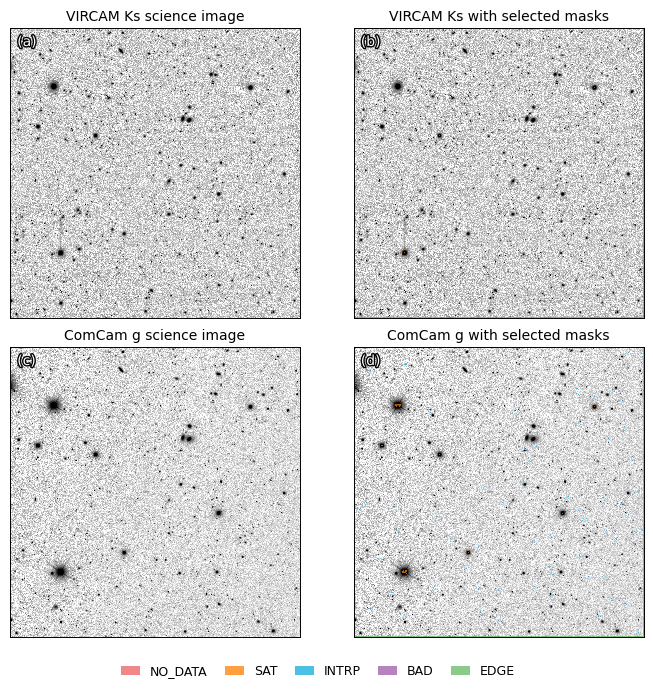

Saved PDF: data/image_products/dp1_ecdfs_image_mask_tract_5063_patch_22.pdf


In [5]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(7.0, 7.0),
)

panel_specs = [
    {
        "axis": axes[0, 0],
        "image": vista_image,
        "norm": vista_norm,
        "overlay": None,
        "title": r"VIRCAM Ks science image",
        "panel": "(a)",
    },
    {
        "axis": axes[0, 1],
        "image": vista_image,
        "norm": vista_norm,
        "overlay": vista_overlay,
        "title": r"VIRCAM Ks with selected masks",
        "panel": "(b)",
    },
    {
        "axis": axes[1, 0],
        "image": comcam_image,
        "norm": comcam_norm,
        "overlay": None,
        "title": r"ComCam g science image",
        "panel": "(c)",
    },
    {
        "axis": axes[1, 1],
        "image": comcam_image,
        "norm": comcam_norm,
        "overlay": comcam_overlay,
        "title": r"ComCam g with selected masks",
        "panel": "(d)",
    },
]


for spec in panel_specs:
    ax = spec["axis"]

    ax.imshow(
        spec["image"],
        origin="lower",
        cmap=SCIENCE_CMAP,
        norm=spec["norm"],
        interpolation="none",
    )

    if spec["overlay"] is not None:
        ax.imshow(
            spec["overlay"],
            origin="lower",
            interpolation="nearest",
        )

    ax.text(
        0.025,
        0.975,
        spec["panel"],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=10,
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground="black",
            )
        ],
    )

    ax.set_title(
        spec["title"],
        fontsize=10,
        pad=5,
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("black")


legend_handles = [
    Patch(
        facecolor=MASK_STYLES[plane]["color"],
        edgecolor="none",
        alpha=MASK_STYLES[plane]["alpha"],
        label=MASK_STYLES[plane]["label"],
    )
    for plane in MASK_PLANES
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    bbox_to_anchor=(0.5, 0.015),
    frameon=False,
    fontsize=9,
    handlelength=1.5,
    columnspacing=1.4,
)

fig.subplots_adjust(
    left=0.03,
    right=0.995,
    bottom=0.09,
    top=0.96,
    wspace=0.035,
    hspace=0.10,
)

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

print("Saved PDF:", OUTPUT_PDF)

### 6. Compare the VIRCAM and ComCam survey footprints

This section identifies a representative region where the VIRCAM and ComCam coverage boundaries differ clearly. Common patches in the selected tract are searched for a cutout containing both valid and NO_DATA pixels while avoiding regions that are almost entirely outside the survey footprint.

The selected region is then shown as a four-panel comparison of the VIRCAM $K_s$ and ComCam $g$ science images and their corresponding categorical mask maps. Using identical pixel coordinates makes the difference between the optical and near-infrared survey footprints directly visible.

Searching 47 common patches in tract 5063.


,score,patch,x0,y0,window,g_no_fraction,k_no_fraction,difference_fraction,g_valid_fraction,k_valid_fraction
0,2.717178,41,1800,600,900,0.657686,0.0,0.657686,0.342314,1.0


Selected tract 5063, patch 41
ComCam valid fraction: 0.342
VIRCAM valid fraction: 1.000
Survey-footprint disagreement: 0.658


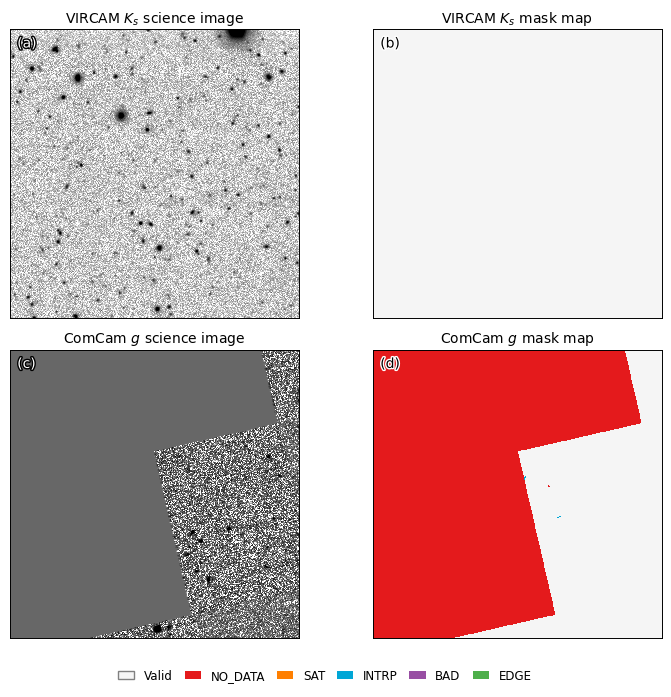

Saved PDF: data/image_products/dp1_ecdfs_image_mask_boundary_tract_5063_patch_41.pdf


In [6]:
# ------------------------------------------------------------
# Find a representative footprint-boundary region and create
# a science-image + categorical-mask 2 x 2 figure
# ------------------------------------------------------------

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


# Size of the displayed boundary region.
# 900 pixels corresponds to about 3 arcmin at 0.2 arcsec/pixel.
BOUNDARY_CUTOUT_SIZE_PIX = 900

# Search step within each patch.
BOUNDARY_SEARCH_STRIDE_PIX = 300


# ------------------------------------------------------------
# Helpers for loading arbitrary patches
# ------------------------------------------------------------

def load_comcam_patch(band, patch):
    """Load one ComCam coadd for an arbitrary patch."""
    refs = list(
        set(
            butler_comcam.query_datasets(
                COMCAM_DATASET_TYPE,
                tract=TRACT,
                patch=int(patch),
                where=f"band = '{band}'",
            )
        )
    )

    if not refs:
        raise RuntimeError(
            f"No ComCam {band}-band coadd for patch {patch}."
        )

    ref = sorted(
        refs,
        key=lambda item: str(item.run),
    )[-1]

    return butler_comcam.get(ref), ref


def load_vista_patch(band, patch):
    """Load the preferred VIRCAM coadd for an arbitrary patch."""
    refs = list(
        set(
            registry_vista.queryDatasets(
                VIRCAM_DATASET_TYPE,
                dataId={
                    "skymap": SKYMAP,
                    "tract": TRACT,
                    "patch": int(patch),
                    "band": band,
                },
                collections=VIRCAM_SEARCH_COLLECTIONS,
            )
        )
    )

    if not refs:
        raise RuntimeError(
            f"No VIRCAM {band}-band coadd for patch {patch}."
        )

    preferred = [
        ref
        for ref in refs
        if ref.run == VIRCAM_PREFERRED_RUN
    ]

    if preferred:
        ref = preferred[0]
    else:
        ref = sorted(
            refs,
            key=lambda item: str(item.run),
        )[-1]

    return butler_vista.get(ref), ref


def bbox_signature(bbox):
    """Return the integer geometry of an LSST bounding box."""
    return (
        bbox.getMinX(),
        bbox.getMinY(),
        bbox.getWidth(),
        bbox.getHeight(),
    )


# ------------------------------------------------------------
# Fast window-statistic helpers
# ------------------------------------------------------------

def integral_image(boolean_array):
    """Return a zero-padded summed-area table."""
    array = np.asarray(
        boolean_array,
        dtype=np.int64,
    )

    integral = array.cumsum(axis=0).cumsum(axis=1)

    return np.pad(
        integral,
        ((1, 0), (1, 0)),
        mode="constant",
        constant_values=0,
    )


def integral_window_sum(
    integral,
    y0,
    x0,
    height,
    width,
):
    """Return the sum inside one rectangular window."""
    y1 = y0 + height
    x1 = x0 + width

    return (
        integral[y1, x1]
        - integral[y0, x1]
        - integral[y1, x0]
        + integral[y0, x0]
    )


def candidate_starts(length, window, stride):
    """Return search-window starting positions including the final edge."""
    if window >= length:
        return [0]

    starts = list(
        range(
            0,
            length - window + 1,
            stride,
        )
    )

    final_start = length - window

    if starts[-1] != final_start:
        starts.append(final_start)

    return starts


# ------------------------------------------------------------
# Find patches available in both selected bands
# ------------------------------------------------------------

comcam_refs = list(
    set(
        butler_comcam.query_datasets(
            COMCAM_DATASET_TYPE,
            tract=TRACT,
            where=f"band = '{COMCAM_BAND}'",
        )
    )
)

vista_refs = list(
    set(
        registry_vista.queryDatasets(
            VIRCAM_DATASET_TYPE,
            dataId={
                "skymap": SKYMAP,
                "tract": TRACT,
                "band": VIRCAM_BAND,
            },
            collections=VIRCAM_SEARCH_COLLECTIONS,
        )
    )
)

comcam_patches = {
    int(ref.dataId["patch"])
    for ref in comcam_refs
}

vista_patches = {
    int(ref.dataId["patch"])
    for ref in vista_refs
}

common_patches = sorted(
    comcam_patches & vista_patches
)

print(
    f"Searching {len(common_patches)} common patches "
    f"in tract {TRACT}."
)


# ------------------------------------------------------------
# Search for a representative boundary cutout
# ------------------------------------------------------------

best_candidate = None

for patch in common_patches:
    try:
        g_exposure, _ = load_comcam_patch(
            COMCAM_BAND,
            patch,
        )

        k_exposure, _ = load_vista_patch(
            VIRCAM_BAND,
            patch,
        )

        if (
            bbox_signature(g_exposure.getBBox())
            != bbox_signature(k_exposure.getBBox())
        ):
            continue

        g_no_data = plane_boolean_mask(
            g_exposure.mask,
            "NO_DATA",
        )

        k_no_data = plane_boolean_mask(
            k_exposure.mask,
            "NO_DATA",
        )

        # Other selected mask categories help prefer an informative,
        # but not pathological, region.
        g_other = np.zeros(
            g_no_data.shape,
            dtype=bool,
        )
        k_other = np.zeros(
            k_no_data.shape,
            dtype=bool,
        )

        for plane in ["SAT", "INTRP", "BAD", "EDGE"]:
            g_other |= plane_boolean_mask(
                g_exposure.mask,
                plane,
            )

            k_other |= plane_boolean_mask(
                k_exposure.mask,
                plane,
            )

        disagreement = g_no_data != k_no_data

        height, width = g_no_data.shape

        window = min(
            BOUNDARY_CUTOUT_SIZE_PIX,
            height,
            width,
        )

        area = window * window

        g_no_data_integral = integral_image(g_no_data)
        k_no_data_integral = integral_image(k_no_data)
        disagreement_integral = integral_image(disagreement)
        g_other_integral = integral_image(g_other)
        k_other_integral = integral_image(k_other)

        x_starts = candidate_starts(
            width,
            window,
            BOUNDARY_SEARCH_STRIDE_PIX,
        )

        y_starts = candidate_starts(
            height,
            window,
            BOUNDARY_SEARCH_STRIDE_PIX,
        )

        for y0 in y_starts:
            for x0 in x_starts:
                g_no_fraction = (
                    integral_window_sum(
                        g_no_data_integral,
                        y0,
                        x0,
                        window,
                        window,
                    )
                    / area
                )

                k_no_fraction = (
                    integral_window_sum(
                        k_no_data_integral,
                        y0,
                        x0,
                        window,
                        window,
                    )
                    / area
                )

                difference_fraction = (
                    integral_window_sum(
                        disagreement_integral,
                        y0,
                        x0,
                        window,
                        window,
                    )
                    / area
                )

                other_fraction = (
                    integral_window_sum(
                        g_other_integral,
                        y0,
                        x0,
                        window,
                        window,
                    )
                    + integral_window_sum(
                        k_other_integral,
                        y0,
                        x0,
                        window,
                        window,
                    )
                ) / (2.0 * area)

                g_valid_fraction = 1.0 - g_no_fraction
                k_valid_fraction = 1.0 - k_no_fraction

                # This is largest when a window contains both valid
                # and NO_DATA pixels.
                g_boundary_mix = (
                    4.0
                    * g_no_fraction
                    * (1.0 - g_no_fraction)
                )

                k_boundary_mix = (
                    4.0
                    * k_no_fraction
                    * (1.0 - k_no_fraction)
                )

                boundary_strength = max(
                    g_boundary_mix,
                    k_boundary_mix,
                )

                common_valid_fraction = min(
                    g_valid_fraction,
                    k_valid_fraction,
                )

                # Avoid windows that are almost completely invalid.
                if common_valid_fraction < 0.20:
                    continue

                # Require a visible footprint edge or substantial
                # disagreement between the two surveys.
                if (
                    boundary_strength < 0.15
                    and difference_fraction < 0.08
                ):
                    continue

                score = (
                    2.0 * difference_fraction
                    + 1.2 * boundary_strength
                    + 0.5 * common_valid_fraction
                    + 0.15
                    * min(
                        other_fraction / 0.02,
                        1.0,
                    )
                )

                candidate = {
                    "score": score,
                    "patch": patch,
                    "x0": x0,
                    "y0": y0,
                    "window": window,
                    "g_no_fraction": g_no_fraction,
                    "k_no_fraction": k_no_fraction,
                    "difference_fraction": difference_fraction,
                    "g_valid_fraction": g_valid_fraction,
                    "k_valid_fraction": k_valid_fraction,
                }

                if (
                    best_candidate is None
                    or score > best_candidate["score"]
                ):
                    best_candidate = candidate

    except Exception as error:
        print(
            f"Skipping patch {patch}: {error}"
        )


if best_candidate is None:
    raise RuntimeError(
        "No representative footprint-boundary region was found. "
        "Try another tract or reduce the boundary-selection criteria."
    )

display(
    pd.DataFrame([best_candidate])
)

selected_patch = best_candidate["patch"]

print(
    f"Selected tract {TRACT}, patch {selected_patch}"
)
print(
    "ComCam valid fraction:",
    f"{best_candidate['g_valid_fraction']:.3f}",
)
print(
    "VIRCAM valid fraction:",
    f"{best_candidate['k_valid_fraction']:.3f}",
)
print(
    "Survey-footprint disagreement:",
    f"{best_candidate['difference_fraction']:.3f}",
)


# ------------------------------------------------------------
# Load the selected patch and extract the common cutout
# ------------------------------------------------------------

comcam_exposure, comcam_ref = load_comcam_patch(
    COMCAM_BAND,
    selected_patch,
)

vista_exposure, vista_ref = load_vista_patch(
    VIRCAM_BAND,
    selected_patch,
)

parent_bbox = comcam_exposure.getBBox()

display_bbox = geom.Box2I(
    geom.Point2I(
        parent_bbox.getMinX()
        + best_candidate["x0"],
        parent_bbox.getMinY()
        + best_candidate["y0"],
    ),
    geom.Extent2I(
        best_candidate["window"],
        best_candidate["window"],
    ),
)

comcam_cutout = comcam_exposure.getCutout(
    display_bbox
)

vista_cutout = vista_exposure.getCutout(
    display_bbox
)

comcam_image = np.asarray(
    comcam_cutout.image.array,
    dtype=float,
)

vista_image = np.asarray(
    vista_cutout.image.array,
    dtype=float,
)

comcam_norm = make_display_normalization(
    comcam_image,
    comcam_cutout.mask,
)

vista_norm = make_display_normalization(
    vista_image,
    vista_cutout.mask,
)


# ------------------------------------------------------------
# Construct categorical mask maps
#
# 0 = valid
# 1 = NO_DATA
# 2 = SAT
# 3 = INTRP
# 4 = BAD
# 5 = EDGE
# ------------------------------------------------------------

CATEGORY_PLANES = [
    "NO_DATA",
    "SAT",
    "INTRP",
    "BAD",
    "EDGE",
]

CATEGORY_VALUES = {
    "NO_DATA": 1,
    "SAT": 2,
    "INTRP": 3,
    "BAD": 4,
    "EDGE": 5,
}

# Later entries overwrite earlier entries.
CATEGORY_PRIORITY = [
    "EDGE",
    "BAD",
    "INTRP",
    "SAT",
    "NO_DATA",
]


def make_categorical_mask(mask):
    """Return one integer categorical mask map."""
    categories = np.zeros(
        mask.array.shape,
        dtype=np.int16,
    )

    for plane in CATEGORY_PRIORITY:
        selected = plane_boolean_mask(
            mask,
            plane,
        )

        categories[selected] = CATEGORY_VALUES[plane]

    return categories


comcam_categories = make_categorical_mask(
    comcam_cutout.mask
)

vista_categories = make_categorical_mask(
    vista_cutout.mask
)


category_colors = [
    "#f5f5f5",  # valid
    MASK_STYLES["NO_DATA"]["color"],
    MASK_STYLES["SAT"]["color"],
    MASK_STYLES["INTRP"]["color"],
    MASK_STYLES["BAD"]["color"],
    MASK_STYLES["EDGE"]["color"],
]

category_cmap = ListedColormap(
    category_colors
)

category_norm = BoundaryNorm(
    np.arange(-0.5, 6.5, 1.0),
    category_cmap.N,
)


# ------------------------------------------------------------
# Four-panel figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(7.4, 7.0),
)

panel_specs = [
    {
        "axis": axes[0, 0],
        "kind": "science",
        "image": vista_image,
        "norm": vista_norm,
        "title": r"VIRCAM $K_s$ science image",
        "panel": "(a)",
    },
    {
        "axis": axes[0, 1],
        "kind": "mask",
        "image": vista_categories,
        "title": r"VIRCAM $K_s$ mask map",
        "panel": "(b)",
    },
    {
        "axis": axes[1, 0],
        "kind": "science",
        "image": comcam_image,
        "norm": comcam_norm,
        "title": r"ComCam $g$ science image",
        "panel": "(c)",
    },
    {
        "axis": axes[1, 1],
        "kind": "mask",
        "image": comcam_categories,
        "title": r"ComCam $g$ mask map",
        "panel": "(d)",
    },
]


for spec in panel_specs:
    ax = spec["axis"]

    if spec["kind"] == "science":
        ax.imshow(
            spec["image"],
            origin="lower",
            cmap=SCIENCE_CMAP,
            norm=spec["norm"],
            interpolation="none",
        )

        label_color = "white"
        stroke_color = "black"

    else:
        ax.imshow(
            spec["image"],
            origin="lower",
            cmap=category_cmap,
            norm=category_norm,
            interpolation="nearest",
        )

        label_color = "black"
        stroke_color = "white"

    ax.text(
        0.025,
        0.975,
        spec["panel"],
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=label_color,
        fontsize=10,
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground=stroke_color,
            )
        ],
    )

    ax.set_title(
        spec["title"],
        fontsize=10,
        pad=5,
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("black")


legend_handles = [
    Patch(
        facecolor=category_colors[0],
        edgecolor="0.5",
        label="Valid",
    ),
    Patch(
        facecolor=MASK_STYLES["NO_DATA"]["color"],
        edgecolor="none",
        label="NO_DATA",
    ),
    Patch(
        facecolor=MASK_STYLES["SAT"]["color"],
        edgecolor="none",
        label="SAT",
    ),
    Patch(
        facecolor=MASK_STYLES["INTRP"]["color"],
        edgecolor="none",
        label="INTRP",
    ),
    Patch(
        facecolor=MASK_STYLES["BAD"]["color"],
        edgecolor="none",
        label="BAD",
    ),
    Patch(
        facecolor=MASK_STYLES["EDGE"]["color"],
        edgecolor="none",
        label="EDGE",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, 0.012),
    frameon=False,
    fontsize=8.5,
    handlelength=1.4,
    columnspacing=1.0,
)

fig.subplots_adjust(
    left=0.035,
    right=0.995,
    bottom=0.09,
    top=0.96,
    wspace=0.045,
    hspace=0.11,
)


boundary_output_pdf = OUTDIR / (
    f"dp1_ecdfs_image_mask_boundary_"
    f"tract_{TRACT}_patch_{selected_patch}.pdf"
)

boundary_output_png = OUTDIR / (
    f"dp1_ecdfs_image_mask_boundary_"
    f"tract_{TRACT}_patch_{selected_patch}.png"
)

fig.savefig(
    boundary_output_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)


plt.show()

print("Saved PDF:", boundary_output_pdf)

### 7. Inspect the VIRCAM coadd product components

This section examines the main components of a VIRCAM $K_s$ coadd using a representative, mostly valid cutout containing a small fraction of masked pixels. The four panels show the science image, $1\sigma$ pixel uncertainty derived from the variance plane, selected mask planes, and the corresponding per-pixel signal-to-noise ratio.

Pixels flagged as NO_DATA, BAD, EDGE, SAT, or INTRP are excluded from the signal-to-noise calculation. This provides a compact view of how the science, variance, and mask information should be interpreted together.

Selected cutout:
  tract: 5063
  patch: 22
  size: 900 x 900
  valid fraction: 1.0000
  selected-mask fraction: 0.013591


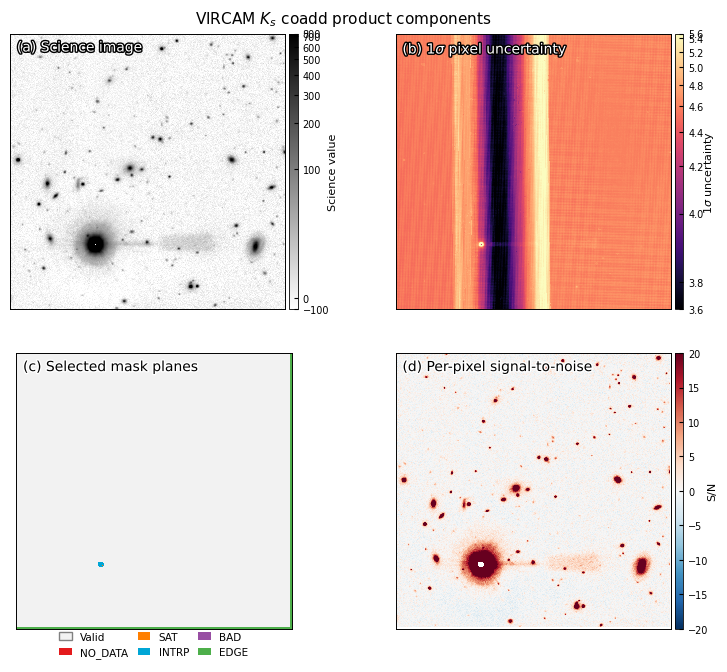

Saved PDF: data/image_products/dp1_ecdfs_coadd_product_components_tract_5063_patch_22_Ks.pdf


In [7]:
# ------------------------------------------------------------
# Coadd product anatomy:
# science image, uncertainty, selected masks, and per-pixel S/N
# ------------------------------------------------------------

from matplotlib.colors import (
    BoundaryNorm,
    ListedColormap,
    Normalize,
)
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

PRODUCT_CUTOUT_SIZE_PIX = 900
PRODUCT_SEARCH_STRIDE_PIX = 250

PRODUCT_OUTPUT_PDF = OUTDIR / (
    f"dp1_ecdfs_coadd_product_components_"
    f"tract_{TRACT}_patch_{PATCH}_Ks.pdf"
)

PRODUCT_OUTPUT_PNG = OUTDIR / (
    f"dp1_ecdfs_coadd_product_components_"
    f"tract_{TRACT}_patch_{PATCH}_Ks.png"
)


# Pixels excluded from the S/N calculation.
SN_EXCLUDED_PLANES = [
    "NO_DATA",
    "BAD",
    "EDGE",
    "SAT",
    "INTRP",
]


# ------------------------------------------------------------
# Select a mostly valid cutout containing representative masks
# ------------------------------------------------------------

def summed_area_table(boolean_array):
    """Create a zero-padded summed-area table."""
    array = np.asarray(
        boolean_array,
        dtype=np.int64,
    )

    table = array.cumsum(axis=0).cumsum(axis=1)

    return np.pad(
        table,
        ((1, 0), (1, 0)),
        mode="constant",
        constant_values=0,
    )


def window_sum(table, y0, x0, height, width):
    """Return the sum within one rectangular window."""
    y1 = y0 + height
    x1 = x0 + width

    return (
        table[y1, x1]
        - table[y0, x1]
        - table[y1, x0]
        + table[y0, x0]
    )


def search_starts(length, window, stride):
    """Return regular window starts, including the final edge."""
    if window >= length:
        return [0]

    starts = list(
        range(
            0,
            length - window + 1,
            stride,
        )
    )

    final_start = length - window

    if starts[-1] != final_start:
        starts.append(final_start)

    return starts


parent_bbox = vista_exposure.getBBox()
parent_mask = vista_exposure.mask

no_data = plane_boolean_mask(
    parent_mask,
    "NO_DATA",
)

selected_features = np.zeros(
    no_data.shape,
    dtype=bool,
)

for plane in ["SAT", "INTRP", "BAD", "EDGE"]:
    selected_features |= plane_boolean_mask(
        parent_mask,
        plane,
    )


height, width = no_data.shape

window_size = min(
    PRODUCT_CUTOUT_SIZE_PIX,
    height,
    width,
)

window_area = window_size**2

no_data_table = summed_area_table(no_data)
feature_table = summed_area_table(selected_features)

x_starts = search_starts(
    width,
    window_size,
    PRODUCT_SEARCH_STRIDE_PIX,
)

y_starts = search_starts(
    height,
    window_size,
    PRODUCT_SEARCH_STRIDE_PIX,
)

best_region = None

for y0 in y_starts:
    for x0 in x_starts:
        no_data_count = window_sum(
            no_data_table,
            y0,
            x0,
            window_size,
            window_size,
        )

        feature_count = window_sum(
            feature_table,
            y0,
            x0,
            window_size,
            window_size,
        )

        valid_fraction = (
            1.0
            - no_data_count / window_area
        )

        feature_fraction = (
            feature_count / window_area
        )

        # Require an ordinary, mostly valid science region.
        if valid_fraction < 0.97:
            continue

        # Prefer some representative mask information, but avoid
        # selecting a region dominated by masked pixels.
        if feature_fraction > 0.05:
            continue

        score = (
            valid_fraction
            + 5.0 * np.sqrt(feature_fraction)
        )

        candidate = {
            "score": score,
            "x0": x0,
            "y0": y0,
            "valid_fraction": valid_fraction,
            "feature_fraction": feature_fraction,
        }

        if (
            best_region is None
            or score > best_region["score"]
        ):
            best_region = candidate


if best_region is None:
    raise RuntimeError(
        "No suitable mostly valid cutout was found. "
        "Reduce PRODUCT_CUTOUT_SIZE_PIX or lower the "
        "valid-fraction requirement."
    )


display_bbox = geom.Box2I(
    geom.Point2I(
        parent_bbox.getMinX()
        + best_region["x0"],
        parent_bbox.getMinY()
        + best_region["y0"],
    ),
    geom.Extent2I(
        window_size,
        window_size,
    ),
)

product_cutout = vista_exposure.getCutout(
    display_bbox
)

print("Selected cutout:")
print("  tract:", TRACT)
print("  patch:", PATCH)
print("  size:", window_size, "x", window_size)
print(
    "  valid fraction:",
    f"{best_region['valid_fraction']:.4f}",
)
print(
    "  selected-mask fraction:",
    f"{best_region['feature_fraction']:.6f}",
)


# ------------------------------------------------------------
# Extract the image, variance, uncertainty, and mask arrays
# ------------------------------------------------------------

science = np.asarray(
    product_cutout.image.array,
    dtype=float,
)

variance = np.asarray(
    product_cutout.variance.array,
    dtype=float,
)

uncertainty = np.full(
    variance.shape,
    np.nan,
    dtype=float,
)

valid_variance = (
    np.isfinite(variance)
    & (variance > 0)
)

uncertainty[valid_variance] = np.sqrt(
    variance[valid_variance]
)


# ------------------------------------------------------------
# Construct the categorical mask map
#
# 0 = valid
# 1 = NO_DATA
# 2 = SAT
# 3 = INTRP
# 4 = BAD
# 5 = EDGE
# ------------------------------------------------------------

MASK_CATEGORY_VALUES = {
    "NO_DATA": 1,
    "SAT": 2,
    "INTRP": 3,
    "BAD": 4,
    "EDGE": 5,
}

MASK_CATEGORY_PRIORITY = [
    "EDGE",
    "BAD",
    "INTRP",
    "SAT",
    "NO_DATA",
]

mask_categories = np.zeros(
    science.shape,
    dtype=np.int16,
)

for plane in MASK_CATEGORY_PRIORITY:
    selected = plane_boolean_mask(
        product_cutout.mask,
        plane,
    )

    mask_categories[selected] = (
        MASK_CATEGORY_VALUES[plane]
    )


mask_colours = [
    "#f2f2f2",                    # valid
    MASK_STYLES["NO_DATA"]["color"],
    MASK_STYLES["SAT"]["color"],
    MASK_STYLES["INTRP"]["color"],
    MASK_STYLES["BAD"]["color"],
    MASK_STYLES["EDGE"]["color"],
]

mask_cmap = ListedColormap(mask_colours)

mask_norm = BoundaryNorm(
    np.arange(-0.5, 6.5, 1.0),
    mask_cmap.N,
)


# ------------------------------------------------------------
# Calculate per-pixel S/N after applying the selected masks
# ------------------------------------------------------------

sn_excluded = np.zeros(
    science.shape,
    dtype=bool,
)

for plane in SN_EXCLUDED_PLANES:
    sn_excluded |= plane_boolean_mask(
        product_cutout.mask,
        plane,
    )

sn_valid = (
    np.isfinite(science)
    & np.isfinite(uncertainty)
    & (uncertainty > 0)
    & ~sn_excluded
)

signal_to_noise = np.full(
    science.shape,
    np.nan,
    dtype=float,
)

signal_to_noise[sn_valid] = (
    science[sn_valid]
    / uncertainty[sn_valid]
)


# ------------------------------------------------------------
# Display normalizations
# ------------------------------------------------------------

science_norm = make_display_normalization(
    science,
    product_cutout.mask,
)


uncertainty_values = uncertainty[
    np.isfinite(uncertainty)
    & ~plane_boolean_mask(
        product_cutout.mask,
        "NO_DATA",
    )
]

uncertainty_vmin, uncertainty_vmax = np.percentile(
    uncertainty_values,
    [1.0, 99.0],
)

uncertainty_norm = ImageNormalize(
    vmin=uncertainty_vmin,
    vmax=uncertainty_vmax,
    stretch=AsinhStretch(a=0.15),
    clip=True,
)


sn_values = signal_to_noise[
    np.isfinite(signal_to_noise)
]

sn_limit = np.percentile(
    np.abs(sn_values),
    99.0,
)

# Avoid an excessively broad colour range caused by a very
# bright or saturated source.
sn_limit = min(
    sn_limit,
    20.0,
)

sn_norm = Normalize(
    vmin=-sn_limit,
    vmax=sn_limit,
)


# ------------------------------------------------------------
# Four-panel figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(7.6, 7.0),
)

ax_science = axes[0, 0]
ax_uncertainty = axes[0, 1]
ax_mask = axes[1, 0]
ax_sn = axes[1, 1]


science_image = ax_science.imshow(
    science,
    origin="lower",
    cmap=SCIENCE_CMAP,
    norm=science_norm,
    interpolation="none",
)

uncertainty_image = ax_uncertainty.imshow(
    uncertainty,
    origin="lower",
    cmap="magma",
    norm=uncertainty_norm,
    interpolation="none",
)

mask_image = ax_mask.imshow(
    mask_categories,
    origin="lower",
    cmap=mask_cmap,
    norm=mask_norm,
    interpolation="nearest",
)

sn_image = ax_sn.imshow(
    signal_to_noise,
    origin="lower",
    cmap="RdBu_r",
    norm=sn_norm,
    interpolation="none",
)


panel_information = [
    (
        ax_science,
        r"(a) Science image",
        "white",
        "black",
    ),
    (
        ax_uncertainty,
        r"(b) $1\sigma$ pixel uncertainty",
        "white",
        "black",
    ),
    (
        ax_mask,
        r"(c) Selected mask planes",
        "black",
        "white",
    ),
    (
        ax_sn,
        r"(d) Per-pixel signal-to-noise",
        "black",
        "white",
    ),
]

for ax, label, colour, stroke in panel_information:
    ax.text(
        0.025,
        0.975,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=colour,
        fontsize=10,
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground=stroke,
            )
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("black")


# ------------------------------------------------------------
# Slim colourbars
# ------------------------------------------------------------

def append_colourbar(
    fig,
    ax,
    image,
    label,
):
    """Append a narrow colourbar to one image panel."""
    divider = make_axes_locatable(ax)

    cax = divider.append_axes(
        "right",
        size="3%",
        pad=0.04,
    )

    cbar = fig.colorbar(
        image,
        cax=cax,
    )

    cbar.set_label(
        label,
        fontsize=8,
        labelpad=-1,
    )

    cbar.ax.tick_params(
        labelsize=7,
        length=3,
        direction="in",
    )

    cbar.outline.set_linewidth(0.6)


append_colourbar(
    fig,
    ax_science,
    science_image,
    "Science value",
)

append_colourbar(
    fig,
    ax_uncertainty,
    uncertainty_image,
    r"$1\sigma$ uncertainty",
)

append_colourbar(
    fig,
    ax_sn,
    sn_image,
    "S/N",
)


# ------------------------------------------------------------
# Categorical mask legend
# ------------------------------------------------------------

mask_legend_handles = [
    Patch(
        facecolor=mask_colours[0],
        edgecolor="0.5",
        label="Valid",
    ),
    Patch(
        facecolor=MASK_STYLES["NO_DATA"]["color"],
        edgecolor="none",
        label="NO_DATA",
    ),
    Patch(
        facecolor=MASK_STYLES["SAT"]["color"],
        edgecolor="none",
        label="SAT",
    ),
    Patch(
        facecolor=MASK_STYLES["INTRP"]["color"],
        edgecolor="none",
        label="INTRP",
    ),
    Patch(
        facecolor=MASK_STYLES["BAD"]["color"],
        edgecolor="none",
        label="BAD",
    ),
    Patch(
        facecolor=MASK_STYLES["EDGE"]["color"],
        edgecolor="none",
        label="EDGE",
    ),
]

ax_mask.legend(
    handles=mask_legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=3,
    frameon=False,
    fontsize=7.5,
    handlelength=1.2,
    columnspacing=0.9,
)


fig.suptitle(
    rf"VIRCAM $K_s$ coadd product components",
    fontsize=11,
    y=0.985,
)

fig.subplots_adjust(
    left=0.04,
    right=0.97,
    bottom=0.10,
    top=0.95,
    wspace=0.20,
    hspace=0.16,
)


fig.savefig(
    PRODUCT_OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)


plt.show()

print("Saved PDF:", PRODUCT_OUTPUT_PDF)

### 8. Compare full-patch science and uncertainty images

Finally, the complete native patch is used to compare the science and uncertainty planes for VIRCAM $K_s$ and ComCam $r$. The variance planes are converted to $1\sigma$ pixel uncertainties, and NO_DATA pixels are excluded from the displayed arrays.

The resulting four-panel figure shows the VIRCAM and ComCam science images alongside their corresponding uncertainty maps, allowing the spatial structure of the image depth and uncertainty to be compared across the near-infrared and optical coadds.

VIRCAM K: tract=5063, patch=22, run=u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
ComCam r: tract=5063, patch=22, run=LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
Loaded ComCam r: deep_coadd, run=LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
VIRCAM shape: (3400, 3400)
ComCam shape: (3400, 3400)


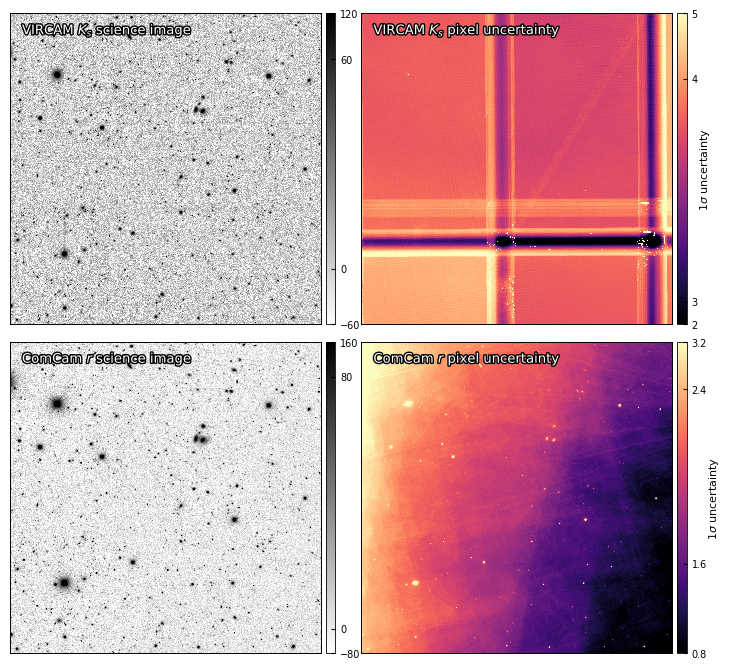

Saved PDF: data/image_products/dp1_ecdfs_science_uncertainty_tract_5063_patch_22_Ks_r.pdf
Saved PNG: data/image_products/dp1_ecdfs_science_uncertainty_tract_5063_patch_22_Ks_r.png


In [8]:
# ------------------------------------------------------------
# Full native-patch coadd components
#
# Top row:
#   VIRCAM Ks science image
#   VIRCAM Ks 1-sigma pixel uncertainty
#
# Bottom row:
#   ComCam r science image
#   ComCam r 1-sigma pixel uncertainty
# ------------------------------------------------------------

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MaxNLocator

OPTICAL_BAND = "r"

COMPONENT_OUTPUT_PDF = OUTDIR / (
    f"dp1_ecdfs_science_uncertainty_"
    f"tract_{TRACT}_patch_{PATCH}_Ks_{OPTICAL_BAND}.pdf"
)

COMPONENT_OUTPUT_PNG = OUTDIR / (
    f"dp1_ecdfs_science_uncertainty_"
    f"tract_{TRACT}_patch_{PATCH}_Ks_{OPTICAL_BAND}.png"
)


# ------------------------------------------------------------
# Load the two coadds
# ------------------------------------------------------------

COMPONENT_PATCH = 22
OPTICAL_BAND = "r"

nir_exposure, nir_ref = load_vista_patch(
    "K",
    COMPONENT_PATCH,
)

optical_exposure, optical_ref = load_comcam_patch(
    OPTICAL_BAND,
    COMPONENT_PATCH,
)

print(
    f"VIRCAM K: tract={TRACT}, patch={COMPONENT_PATCH}, "
    f"run={nir_ref.run}"
)

print(
    f"ComCam {OPTICAL_BAND}: tract={TRACT}, "
    f"patch={COMPONENT_PATCH}, run={optical_ref.run}"
)
print(
    f"Loaded ComCam {OPTICAL_BAND}: "
    f"{optical_ref.datasetType.name}, "
    f"run={optical_ref.run}"
)

print("VIRCAM shape:", nir_exposure.image.array.shape)
print("ComCam shape:", optical_exposure.image.array.shape)


# ------------------------------------------------------------
# Extract each complete native patch
# ------------------------------------------------------------

nir_science = np.asarray(
    nir_exposure.image.array,
    dtype=float,
).copy()

nir_variance = np.asarray(
    nir_exposure.variance.array,
    dtype=float,
).copy()

optical_science = np.asarray(
    optical_exposure.image.array,
    dtype=float,
).copy()

optical_variance = np.asarray(
    optical_exposure.variance.array,
    dtype=float,
).copy()


# ------------------------------------------------------------
# Convert variance to 1-sigma uncertainty
# ------------------------------------------------------------

def uncertainty_from_variance(variance):
    """Convert a variance plane to 1-sigma pixel uncertainty."""
    uncertainty = np.full(
        variance.shape,
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(variance)
        & (variance > 0)
    )

    uncertainty[valid] = np.sqrt(
        variance[valid]
    )

    return uncertainty


nir_uncertainty = uncertainty_from_variance(
    nir_variance
)

optical_uncertainty = uncertainty_from_variance(
    optical_variance
)


# ------------------------------------------------------------
# Apply NO_DATA masks
# ------------------------------------------------------------

nir_no_data = plane_boolean_mask(
    nir_exposure.mask,
    "NO_DATA",
)

optical_no_data = plane_boolean_mask(
    optical_exposure.mask,
    "NO_DATA",
)

nir_science[nir_no_data] = np.nan
nir_uncertainty[nir_no_data] = np.nan

optical_science[optical_no_data] = np.nan
optical_uncertainty[optical_no_data] = np.nan


# ------------------------------------------------------------
# Display normalizations
# ------------------------------------------------------------

nir_science_norm = make_display_normalization(
    nir_science,
    nir_exposure.mask,
)

optical_science_norm = make_display_normalization(
    optical_science,
    optical_exposure.mask,
)


def uncertainty_normalization(
    uncertainty,
    lower_percentile=1.0,
    upper_percentile=99.0,
):
    """Construct an asinh normalization for uncertainty values."""
    values = uncertainty[
        np.isfinite(uncertainty)
    ]

    if values.size == 0:
        raise ValueError(
            "No valid uncertainty values are available."
        )

    vmin, vmax = np.percentile(
        values,
        [
            lower_percentile,
            upper_percentile,
        ],
    )

    return ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(a=0.15),
        clip=True,
    )


nir_uncertainty_norm = uncertainty_normalization(
    nir_uncertainty
)

optical_uncertainty_norm = uncertainty_normalization(
    optical_uncertainty
)


# ------------------------------------------------------------
# Colormaps
# ------------------------------------------------------------

science_cmap = plt.get_cmap(
    SCIENCE_CMAP
).copy()

uncertainty_cmap = plt.get_cmap(
    "magma"
).copy()

science_cmap.set_bad("0.70")
uncertainty_cmap.set_bad("0.70")


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(7.2, 6.8),
)

ax_nir_science = axes[0, 0]
ax_nir_uncertainty = axes[0, 1]
ax_optical_science = axes[1, 0]
ax_optical_uncertainty = axes[1, 1]


nir_science_image = ax_nir_science.imshow(
    nir_science,
    origin="lower",
    cmap=science_cmap,
    norm=nir_science_norm,
    interpolation="none",
)

nir_uncertainty_image = ax_nir_uncertainty.imshow(
    nir_uncertainty,
    origin="lower",
    cmap=uncertainty_cmap,
    norm=nir_uncertainty_norm,
    interpolation="none",
)

optical_science_image = ax_optical_science.imshow(
    optical_science,
    origin="lower",
    cmap=science_cmap,
    norm=optical_science_norm,
    interpolation="none",
)

optical_uncertainty_image = ax_optical_uncertainty.imshow(
    optical_uncertainty,
    origin="lower",
    cmap=uncertainty_cmap,
    norm=optical_uncertainty_norm,
    interpolation="none",
)


panel_information = [
    (
        ax_nir_science,
        r" VIRCAM $K_s$ science image",
        "white",
        "black",
    ),
    (
        ax_nir_uncertainty,
        r" VIRCAM $K_s$ pixel uncertainty",
        "white",
        "black",
    ),
    (
        ax_optical_science,
        rf" ComCam ${OPTICAL_BAND}$ science image",
        "white",
        "black",
    ),
    (
        ax_optical_uncertainty,
        rf" ComCam ${OPTICAL_BAND}$ pixel uncertainty",
        "white",
        "black",
    ),
]


for ax, label, colour, stroke in panel_information:
    ax.text(
        0.025,
        0.975,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=colour,
        fontsize=9.5,
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground=stroke,
            )
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("black")


# ------------------------------------------------------------
# Panel-aligned colourbars
# ------------------------------------------------------------

def append_panel_colourbar(
    fig,
    ax,
    mappable,
    label,
):
    divider = make_axes_locatable(ax)

    cax = divider.append_axes(
        "right",
        size="3%",
        pad=0.05,
    )

    cbar = fig.colorbar(
        mappable,
        cax=cax,
    )

    cbar.set_label(
        label,
        fontsize=8,
        labelpad=0,
    )

    # Fewer tick labels, so the top values do not overlap.
    cbar.ax.yaxis.set_major_locator(
        MaxNLocator(nbins=2)
    )

    cbar.ax.tick_params(
        labelsize=7,
        length=3,
        direction="in",
    )

    cbar.outline.set_linewidth(0.6)


append_panel_colourbar(
    fig,
    ax_nir_science,
    nir_science_image,
    "",
)

append_panel_colourbar(
    fig,
    ax_nir_uncertainty,
    nir_uncertainty_image,
    r"$1\sigma$ uncertainty",
)

append_panel_colourbar(
    fig,
    ax_optical_science,
    optical_science_image,
    "",
)

append_panel_colourbar(
    fig,
    ax_optical_uncertainty,
    optical_uncertainty_image,
    r"$1\sigma$ uncertainty",
)


# Keep the panels close together.
fig.subplots_adjust(
    left=0.035,
    right=0.975,
    bottom=0.035,
    top=0.985,
    wspace=0.08,
    hspace=0.035,
)


fig.savefig(
    COMPONENT_OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

fig.savefig(
    COMPONENT_OUTPUT_PNG,
    dpi=250,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

print("Saved PDF:", COMPONENT_OUTPUT_PDF)
print("Saved PNG:", COMPONENT_OUTPUT_PNG)